In [1]:
#cài đặt thư viện
import numpy as np
import cv2
import matplotlib.pyplot as plt
import datetime



## Hyper parameter

# Function another


#### Display image

In [2]:
#display image
def display_image(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,8))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

#### Get url and save image

In [3]:
# Background
img_bg = cv2.imread('bg.png', cv2.IMREAD_COLOR)
# Object
img_obj = cv2.imread('fg.png', cv2.IMREAD_COLOR)


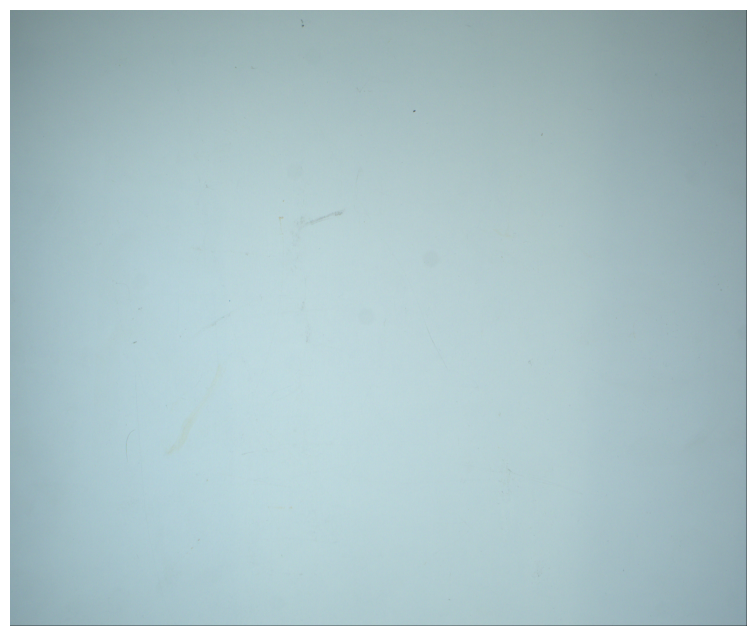

In [4]:
display_image(img_bg)

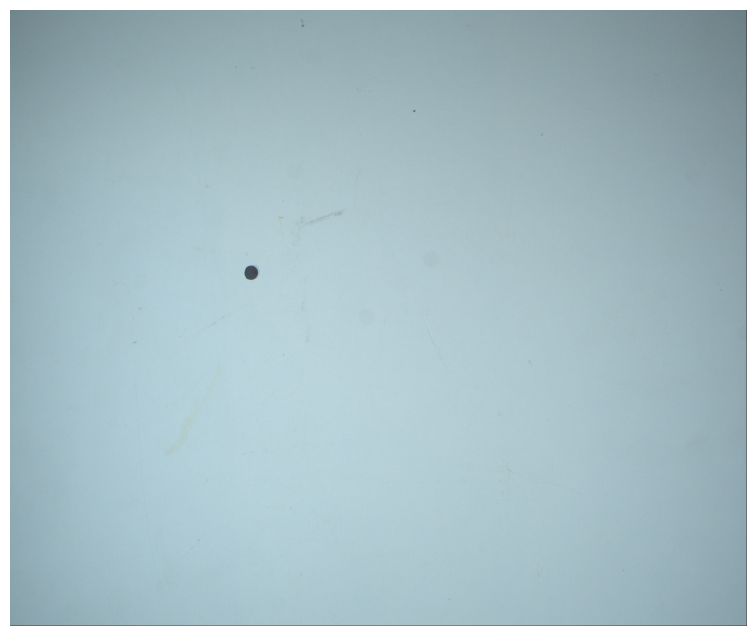

In [5]:
display_image(img_obj)

In [6]:
img_bg.shape

(2048, 2448, 3)

#### Perform Histogram

In [7]:

#using numpy
def performHistogram(img):
    h2 = np.histogram(img.ravel(), bins=256, range=[0,256])
    print(h2[0].shape)
    plt.plot(h2[0])


(256,)


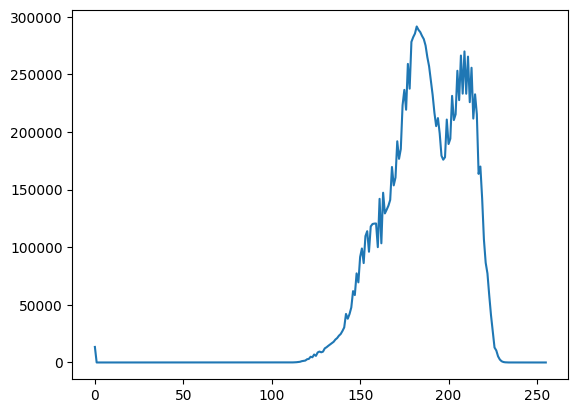

In [8]:
performHistogram(img = img_bg)

#### Preprocessing image

In [9]:
def preprocessing_image(img):
    #convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.multiply(gray, 1.5)
    
    #blur remove noise
    blured1 = cv2.medianBlur(gray,3)
    blured2 = cv2.medianBlur(gray,47)
    divided = np.ma.divide(blured1, blured2).data
    normed = np.uint8(255*divided/divided.max())
    
    #Threshold image
    th, threshed = cv2.threshold(normed, 0, 255,cv2.THRESH_OTSU+  cv2.THRESH_BINARY)
    
    return threshed

In [10]:
#Làm mờ
#blur image
def blur_color_img(img, kernel_width=5, kernel_height=5, sigma_x=2, sigma_y=2):
    #increse brightness for foreground
    
    img = np.copy(img) # we don't modify the original image
    img[:,:,0] = cv2.GaussianBlur(img[:,:,0], ksize=(kernel_width, kernel_height), sigmaX=sigma_x, sigmaY=sigma_y)
    img[:,:,1] = cv2.GaussianBlur(img[:,:,1], ksize=(kernel_width, kernel_height), sigmaX=sigma_x, sigmaY=sigma_y)
    img[:,:,2] = cv2.GaussianBlur(img[:,:,2], ksize=(kernel_width, kernel_height), sigmaX=sigma_x, sigmaY=sigma_y)
    # blured1 = cv2.medianBlur(img,3)
    # blured2 = cv2.medianBlur(img,51)
    # img = cv2.GaussianBlur(img, (5, 5), 0)
    return img

####  Get condinates of the point when clicked

In [11]:

def click_event(event, x, y, flags, params):
    img = img
    # lst = list()
    if event == cv2.EVENT_LBUTTONDOWN:
        #display on shell
        print(x, ' ', y)
        # child_lst = list(x, y)
        # lst.append(child_lst)
        #display on image
        font = cv2.FONT_HERSHEY_SIMPLEX
        cv2.putText(img, str(x) + ',' +
                    str(y), (x,y), font,
                    1, (255, 0, 0), 2)
        cv2.imshow('image', img)
        
    if event == cv2.EVENT_RBUTTONDOWN:
        #display on shell
        print (x, ' ', y)
        # child_lst1 = list(x, y)
        # lst.append(child_lst1)
        #display on screen window
        font = cv2.FONT_HERSHEY_SIMPLEX
        b = img[y, x, 0]
        g = img[y, x, 1]
        r = img[y, x, 2]
        cv2.putText(img, str(b) + ',' +
                    str(g) + ',' + str(r),
                    (x,y), font, 1,
                    (255, 255, 0), 2)
        cv2.imshow('image', img)
    # return lst
        

In [12]:
def roiPoint(img):
    cv2.imshow("image", img)
    cv2.setMouseCallback("image", click_event)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    

#### Get ROI use fillPoly

In [13]:
def roiFillPoly(img, lst):
    points = np.array(lst)
    temp_img = cv2.fillPoly(img, pts = [points], color = (0, 0, 0))    
    return temp_img

#### Binary Image

In [14]:
def binaryImage(img):
    #convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.multiply(gray, 1.5)
    
    #blur remove noise
    blured1 = cv2.medianBlur(gray,3)
    blured2 = cv2.medianBlur(gray,47)
    divided = np.ma.divide(blured1, blured2).data
    normed = np.uint8(255*divided/divided.max())
    
    #Threshold image
    th, threshed = cv2.threshold(normed, 0, 255, cv2.THRESH_OTSU+ cv2.THRESH_BINARY)
    
    return threshed

#### Background Subtraction

In [15]:
#background subtraction
def background_subtraction(fg_img, bg_img, diff_threshold=200):
    fg_img = blur_color_img(fg_img)
    bg_img = blur_color_img(bg_img)
    mask = fg_img - bg_img
    mask = np.abs(mask)
    mask = np.mean(mask, axis=2, keepdims=False)
    mask[mask>diff_threshold] = 255
    mask[mask >= diff_threshold] = 0
    mask = mask.astype(np.uint8)
    mask = cv2.medianBlur(mask, 7)
    return mask

In [16]:
#excute
def main(foreground_img, background_img):
    fg_img = (foreground_img) # [h, w, 3]
    bg_img = (background_img) # [h, w, 3]
    mask = background_subtraction(fg_img, bg_img)
    new_fg = np.zeros([fg_img.shape[0], fg_img.shape[1], 4]) # png image --> has 4-dims instead of 3-dims like color image
    new_fg[:,:,:3] = fg_img
    new_fg[:,:,3] = mask
    cv2.imwrite('mask.jpg', mask)
    cv2.imwrite('test1.png', new_fg)
    display_image(mask)
    return mask

In [17]:
#image processsing of bro. PhamDinhKhanh 
def boudingBox(fg_cropImageRoi, fgMask):
    fg = fg_cropImageRoi.copy()
    cordinate = 0
    #You can choose type connectivity with value about from 4 to 8
    connectivity = 4
    output = cv2.connectedComponentsWithStats(fgMask, connectivity, cv2.CV_32S)
    (numLabels, labels, stats, centroids) = output
    for i in  range(0, numLabels):
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]
        if (area > 3000) and (w > 30) and (h > 30) and (w < fg.shape[0]) and (h < fg.shape[1]):
            cv2.rectangle(fg, (x, y), (x + w, y + h), (0, 255, 0), 10)
            cordinate = [x, y, w, h]
            text = f'({x}, {y})'
            cv2.putText(fg, text, color = (0, 255, 125), org = (x, y-50), fontFace= 1, fontScale= 3, thickness= 5, lineType= 1)
            print(cordinate)
    
    # cv2.imshow('Roi Image 2' , fg)
    time = datetime.datetime.now()
    cv2.imwrite("test_re.png", fg)
    return cordinate, fg

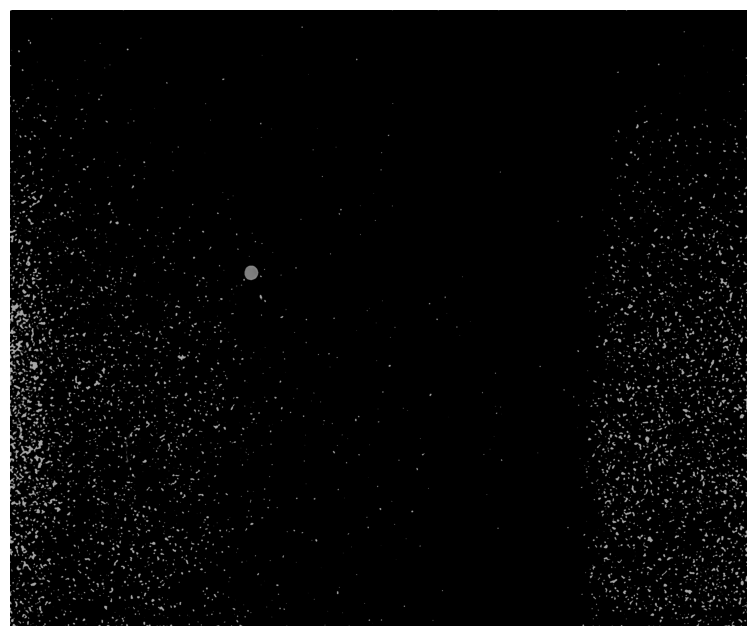

In [18]:
fmask = main(img_obj, img_bg)

In [19]:
coordinate, fg = boudingBox(img_obj, fgMask= fmask)

In [314]:
# coordinate_ori = list(np.asarray(coordinate).astype(int))

In [290]:
# coordinate_ori

In [20]:
#image processsing of bro. PhamDinhKhanh 
def boudingBox(fg_cropImageRoi, fgMask):
    fg = fg_cropImageRoi.copy()
    cordinate = 0
    #You can choose type connectivity with value about from 4 to 8
    connectivity = 4
    output = cv2.connectedComponentsWithStats(fgMask, connectivity, cv2.CV_32S)
    (numLabels, labels, stats, centroids) = output
    for i in  range(0, numLabels):
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]
        if (area > 3000) and (w > 30) and (h > 30) and (w < fg.shape[0]) and (h < fg.shape[1]):
            cv2.rectangle(fg, (x, y), (x + w, y + h), (0, 255, 0), 1)
            cordinate = [x, y, x + w, y + h]
    
    # cv2.imshow('Roi Image 2' , fg)
    time = datetime.datetime.now()
    cv2.imwrite("test/CAM_DBP/result/" + str(str(time).replace(" ","_").replace(":","-").split(".")[0]) + ".png", fg)

    return cordinate, fg

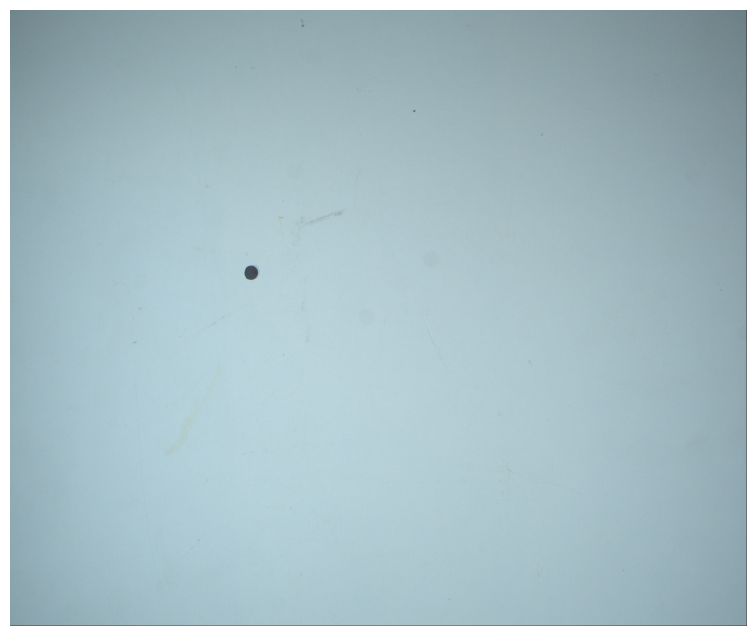

In [21]:
display_image(img_obj)

In [349]:
# Crop
x, y, w, h = coordinate
img_crop = img_obj[y: y+h, x: x+w]

In [350]:
coordinate

[1127, 137, 897, 1739]

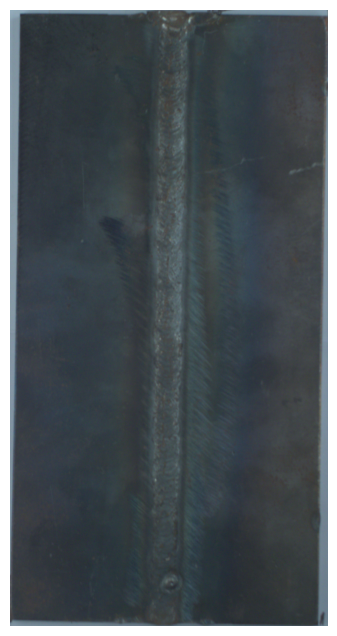

In [351]:
display_image(img_crop)

#### Test

In [1]:
from roboflow import Roboflow
import supervision as sv
import cv2

rf = Roboflow(api_key="JtRFLNmuxFdQiNLXfFJj")
project = rf.workspace().project("final-dataset-rc2vm")
model = project.version(1).model

ConnectionError: HTTPSConnectionPool(host='api.roboflow.com', port=443): Max retries exceeded with url: /?api_key=JtRFLNmuxFdQiNLXfFJj (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x0000020CF8208610>: Failed to resolve 'api.roboflow.com' ([Errno 11001] getaddrinfo failed)"))

In [353]:
result = model.predict(img_crop, confidence=10, overlap=10).json()

weld_seam = [item for item in result["predictions"] if item["class"] not in ['Workpiece']]

In [354]:
weld_seam

[{'x': 459.0,
  'y': 890.0,
  'width': 354.0,
  'height': 1698.0,
  'confidence': 0.321163147687912,
  'class': 'Welding Line',
  'class_id': 1,
  'detection_id': 'e93d3baa-315a-495e-a519-a751b9256080',
  'image_path': array([[[188, 175, 147],
          [187, 178, 146],
          [186, 175, 147],
          ...,
          [143, 138, 126],
          [147, 129, 107],
          [135, 125, 111]],
  
         [[188, 173, 148],
          [188, 175, 150],
          [187, 173, 151],
          ...,
          [142, 143, 130],
          [145, 134, 112],
          [136, 120, 119]],
  
         [[187, 175, 147],
          [189, 171, 151],
          [189, 169, 152],
          ...,
          [152, 147, 126],
          [156, 137, 108],
          [131, 130, 117]],
  
         ...,
  
         [[156, 145, 127],
          [159, 136, 117],
          [148, 135, 120],
          ...,
          [153, 136, 105],
          [153, 136, 113],
          [152, 134, 113]],
  
         [[155, 146, 128],
          [158,

In [355]:
detections = sv.Detections.from_roboflow(result)

SupervisionWarnings: from_roboflow is deprecated: `Detections.from_roboflow` is deprecated and will be removed in `supervision-0.22.0`. Use `Detections.from_inference` instead.


In [356]:
index = list(detections.data['class_name']).index('Welding Line')

In [357]:
coordinate_roboflow = detections.xyxy[index]
x   = int(coordinate_roboflow[0])
y   = int(coordinate_roboflow[1])
x2  = int(coordinate_roboflow[2])
y2  = int(coordinate_roboflow[3])

coordinate_crop = [x, y, x2 - x, y2  - y]

In [256]:
cv2.rectangle(img_crop, (x, y), (x2, y2), (0, 255, 0), 10)

array([[[188, 175, 147],
        [187, 178, 146],
        [186, 175, 147],
        ...,
        [143, 138, 126],
        [147, 129, 107],
        [135, 125, 111]],

       [[188, 173, 148],
        [188, 175, 150],
        [187, 173, 151],
        ...,
        [142, 143, 130],
        [145, 134, 112],
        [136, 120, 119]],

       [[187, 175, 147],
        [189, 171, 151],
        [189, 169, 152],
        ...,
        [152, 147, 126],
        [156, 137, 108],
        [131, 130, 117]],

       ...,

       [[156, 145, 127],
        [159, 136, 117],
        [148, 135, 120],
        ...,
        [153, 136, 105],
        [153, 136, 113],
        [152, 134, 113]],

       [[155, 146, 128],
        [158, 138, 118],
        [149, 134, 122],
        ...,
        [154, 133, 118],
        [153, 135, 115],
        [152, 135, 116]],

       [[159, 146, 127],
        [161, 140, 117],
        [147, 138, 121],
        ...,
        [152, 135, 117],
        [152, 136, 115],
        [153, 135, 116]]

In [ ]:
#Test

In [358]:
coordinate

[1127, 137, 897, 1739]

In [366]:
img_obj = cv2.imread('data/20240419-150246781462-acA2440-35uc_22481496.png', cv2.IMREAD_COLOR)

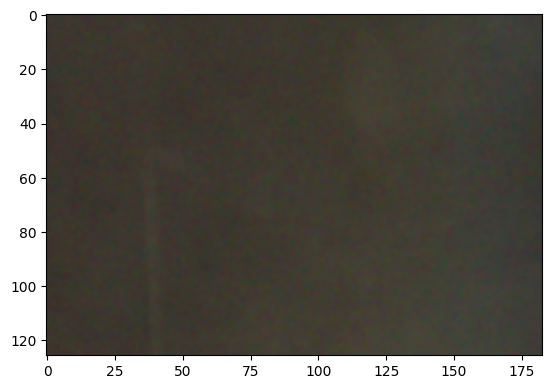

In [370]:
plt.imshow(img_obj[519:519+126, 1865:1865+183])

In [371]:
img = cv2.imread('Test_Module_2.png')
img.shape

(1741, 899, 3)

In [359]:
coordinate_crop

[282, 41, 354, 1698]

In [363]:
x_new = coordinate[0] + coordinate_crop[0]
y_new = coordinate[1] + coordinate_crop[1]
w_new = coordinate_crop[2]
h_new = coordinate_crop[3]

In [361]:
cv2.circle(img_obj, center = (x_new, y_new), color = (255, 0, 125), thickness= 10, radius= 10)

array([[[157, 142, 117],
        [157, 142, 117],
        [157, 146, 115],
        ...,
        [162, 143, 118],
        [161, 143, 123],
        [157, 146, 123]],

       [[157, 142, 117],
        [157, 142, 117],
        [157, 146, 115],
        ...,
        [162, 143, 118],
        [161, 143, 123],
        [157, 146, 123]],

       [[157, 144, 120],
        [157, 144, 120],
        [156, 148, 117],
        ...,
        [161, 145, 121],
        [160, 147, 122],
        [158, 145, 123]],

       ...,

       [[142, 124, 106],
        [142, 124, 106],
        [141, 127, 103],
        ...,
        [136, 124, 104],
        [137, 121, 109],
        [134, 121, 110]],

       [[142, 125, 106],
        [142, 125, 106],
        [141, 128, 102],
        ...,
        [135, 127, 102],
        [136, 125, 103],
        [134, 122, 105]],

       [[137, 127, 107],
        [137, 127, 107],
        [136, 130, 102],
        ...,
        [134, 126, 103],
        [135, 125, 103],
        [139, 119, 104]]

In [364]:
cv2.circle(img_obj, center = (x_new + w_new, y_new + h_new), color = (255, 0, 125), thickness= 10, radius= 10)

array([[[157, 142, 117],
        [157, 142, 117],
        [157, 146, 115],
        ...,
        [162, 143, 118],
        [161, 143, 123],
        [157, 146, 123]],

       [[157, 142, 117],
        [157, 142, 117],
        [157, 146, 115],
        ...,
        [162, 143, 118],
        [161, 143, 123],
        [157, 146, 123]],

       [[157, 144, 120],
        [157, 144, 120],
        [156, 148, 117],
        ...,
        [161, 145, 121],
        [160, 147, 122],
        [158, 145, 123]],

       ...,

       [[142, 124, 106],
        [142, 124, 106],
        [141, 127, 103],
        ...,
        [136, 124, 104],
        [137, 121, 109],
        [134, 121, 110]],

       [[142, 125, 106],
        [142, 125, 106],
        [141, 128, 102],
        ...,
        [135, 127, 102],
        [136, 125, 103],
        [134, 122, 105]],

       [[137, 127, 107],
        [137, 127, 107],
        [136, 130, 102],
        ...,
        [134, 126, 103],
        [135, 125, 103],
        [139, 119, 104]]

In [2]:
display_image(img_obj)

NameError: name 'display_image' is not defined

In [ ]:
#Apendix

mask = 